In [ ]:
using Revise
using ViscousStreaming
using ImmersedLayers
using Plots

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] 


set up exact solution

In [ ]:
Re = 40
ϵ = 0.1
p = ViscousStreaming.StreamingParams(ϵ,Re)
sol = ViscousStreaming.StreamingAnalytical(p, InertialFrame)

Maximum residual on W₁ = 5.684341886080802e-14
BC residual on Ψ₁(1) = 1.1443916996305594e-16
BC residual on dΨ₁(1) = 2.2887833992611187e-16
Maximum residual on Ws₂ = 3.979039320256561e-13
BC residual on Ψs₂(1) = 3.552713678800501e-15
BC residual on dΨs₂(1) = 2.6645352591003757e-15
Maximum residual on W₂ = 1.67181510390182e-12
BC residual on Ψ₂(1) = 2.8609792490763984e-17
BC residual on dΨ₂(1) = 2.220446049250313e-15


Analytical streaming flow solution for
single cylinder with Re = 40.0, ϵ = 0.1


set up plots

In [2]:
spacing = 1.4
Δx = 0.02
Lx = 5.98*2
xlim = (-Lx/2,Lx/2)
ylim = (-Lx/2,Lx/2)
g = PhysicalGrid(xlim,ylim,Δx)
Δs = spacing*cellsize(g)
body = Circle(1.0, Δs)

Circular body with 224 points and radius 1.0
   Current position: (0.0,0.0)
   Current angle (rad): 0.0


In [7]:
cache = SurfaceVectorCache(body, g)

Surface cache with scaling of type GridScaling
  224 point data of type VectorData{224, Float64, Vector{Float64}}
  Grid data of type Edges{Primal, 600, 600, Float64, Vector{Float64}}


In [9]:
s2s = zeros_gridcurl(cache);

In [14]:
x_coord = x_gridcurl(cache)[:,1]
y_coord = y_gridcurl(cache)[1,:]
s2s .= [streamfunction(x, y, 0.0, sol.s2s) for x in x_coord, y in y_coord];

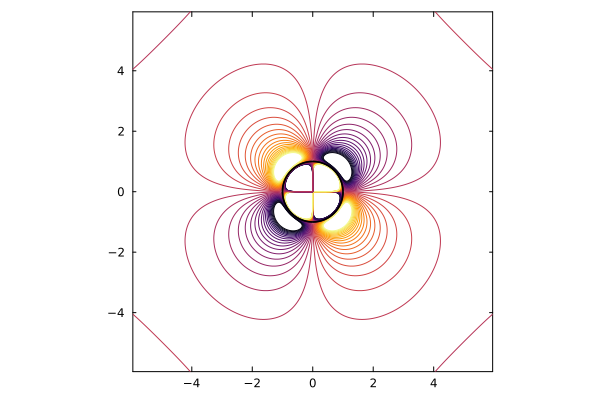

In [19]:
lim = 0.1
plot(s2s, cache, levels=range(-lim, lim, length=40), clim=(-lim, lim))